<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Credit_Card_Fraud_Detection_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection Dataset

# About the dataset

Dataset you are working with is a Credit Card Fraud Detection Dataset, containing 10,000 transaction records and 10 features. It's a clean dataset, as indicated by the absence of missing values or duplicate entries.

Key features include transaction_id, amount, transaction_hour, merchant_category, foreign_transaction, location_mismatch, device_trust_score, velocity_last_24h, cardholder_age, and the target variable, is_fraud.

From the descriptive statistics and univariate analysis, we can glean several insights:

Imbalance: The is_fraud column reveals a significant class imbalance, with only about 1.51% of transactions being fraudulent. This is a crucial observation for any subsequent modeling efforts, as it suggests the need for techniques to handle imbalanced data.
Numerical Distributions: Features like amount, transaction_hour, device_trust_score, velocity_last_24h, and cardholder_age show a range of distributions, from somewhat uniform (transaction_hour) to possibly skewed (e.g., amount, given its max value is significantly higher than the 75th percentile).
Categorical Features: merchant_category is the sole categorical feature, with five distinct categories: Food, Clothing, Travel, Grocery, and Electronics. 'Food' transactions appear to be the most frequent.
Binary Indicators: foreign_transaction and location_mismatch are binary features, indicating whether a transaction occurred abroad or if there was a discrepancy in location. These could be strong predictors of fraud.
Device Trust Score: This feature, ranging from 25 to 99, likely quantifies the perceived trustworthiness of the device used for the transaction, offering another potential indicator for fraud detection.
Correlation: The correlation matrix can help identify relationships between features, particularly how each feature correlates with is_fraud. High correlations could point to strong predictive power.
Overall, the dataset provides a solid foundation for building a fraud detection model, but the class imbalance in the target variable is_fraud will be a primary consideration during model development and evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d miadul/credit-card-fraud-detection-dataset

# Unziping the downloaded file
!unzip credit-card-fraud-detection-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/miadul/credit-card-fraud-detection-dataset
License(s): apache-2.0
  0% 0.00/111k [00:00<?, ?B/s]
100% 111k/111k [00:00<00:00, 291MB/s]
Archive:  credit-card-fraud-detection-dataset.zip
  inflating: credit_card_fraud_10k.csv  


In [3]:
df = pd.read_csv('credit_card_fraud_10k.csv')
df.head(11)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [4]:
df.tail(11)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9989,9990,304.53,2,Travel,0,0,93,0,68,0
9990,9991,107.74,12,Travel,1,0,26,2,39,0
9991,9992,70.78,18,Clothing,0,0,67,1,40,0
9992,9993,114.66,20,Travel,0,0,64,2,51,0
9993,9994,307.41,0,Grocery,0,1,92,1,26,0
9994,9995,23.96,22,Food,0,0,28,2,19,0
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [5]:
df.shape

(10000, 10)

In [6]:
df.columns

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')

In [7]:
df.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64
is_fraud,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [9]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
amount,10000.0,NaN,NaN,NaN,175.949849,175.392827,0.0,50.905,122.095,242.48,1471.04
transaction_hour,10000.0,NaN,NaN,NaN,11.5933,6.922708,0.0,6.0,12.0,18.0,23.0
merchant_category,10000,5,Food,2093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
foreign_transaction,10000.0,NaN,NaN,NaN,0.0978,0.297059,0.0,0.0,0.0,0.0,1.0
location_mismatch,10000.0,NaN,NaN,NaN,0.0857,0.279935,0.0,0.0,0.0,0.0,1.0
device_trust_score,10000.0,NaN,NaN,NaN,61.7989,21.487053,25.0,43.0,62.0,80.0,99.0
velocity_last_24h,10000.0,NaN,NaN,NaN,2.0089,1.432559,0.0,1.0,2.0,3.0,9.0
cardholder_age,10000.0,NaN,NaN,NaN,43.4687,14.979147,18.0,30.0,44.0,56.0,69.0
is_fraud,10000.0,NaN,NaN,NaN,0.0151,0.121957,0.0,0.0,0.0,0.0,1.0


In [10]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

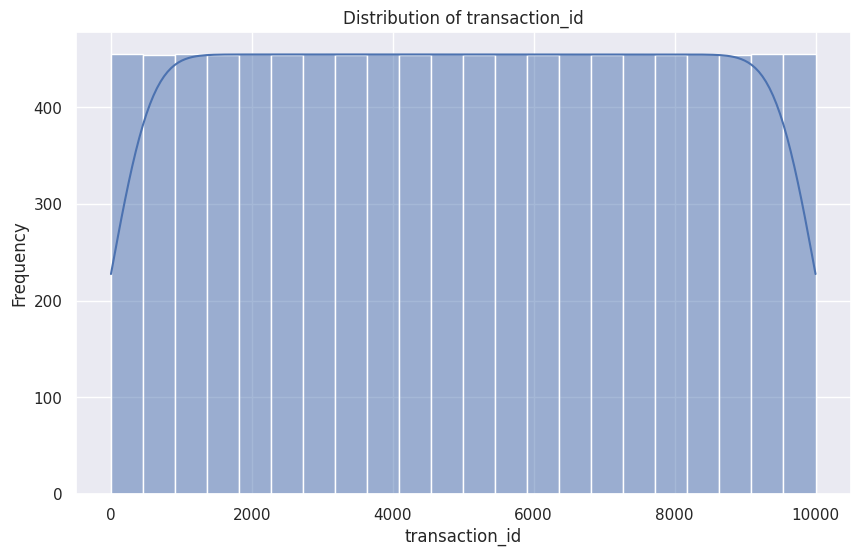

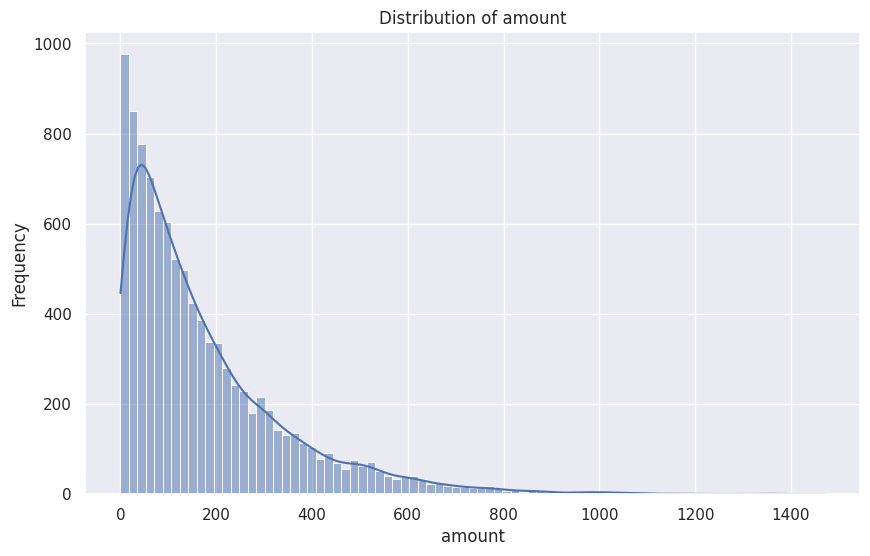

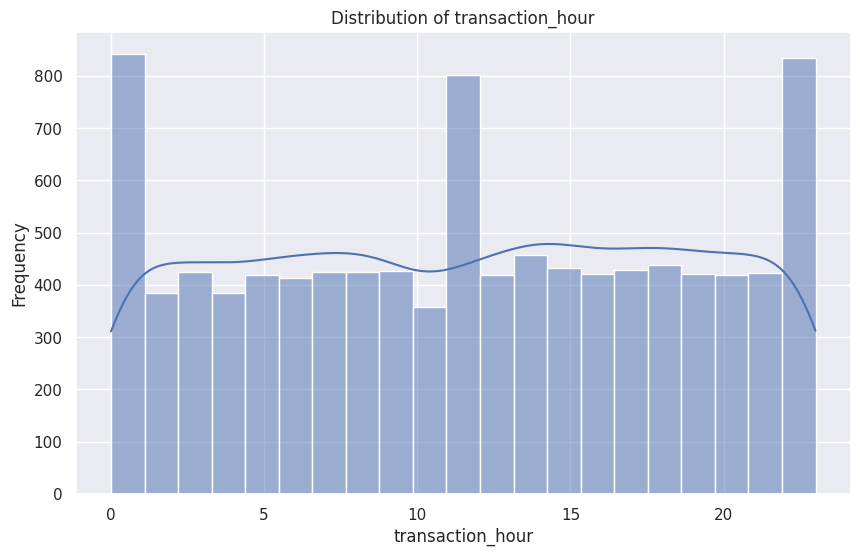

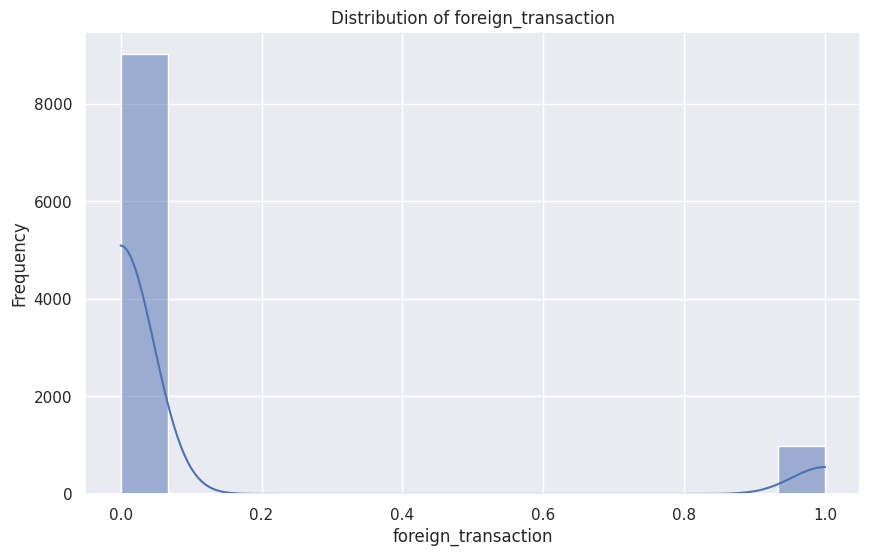

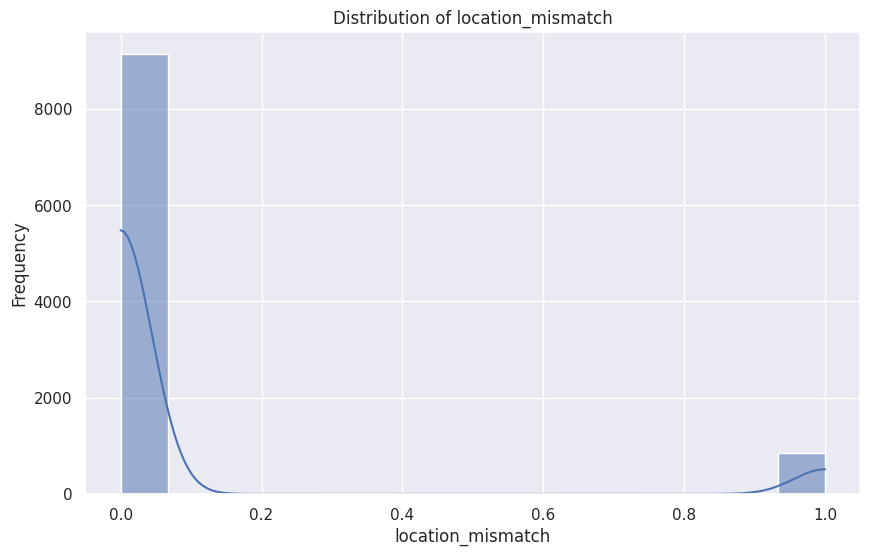

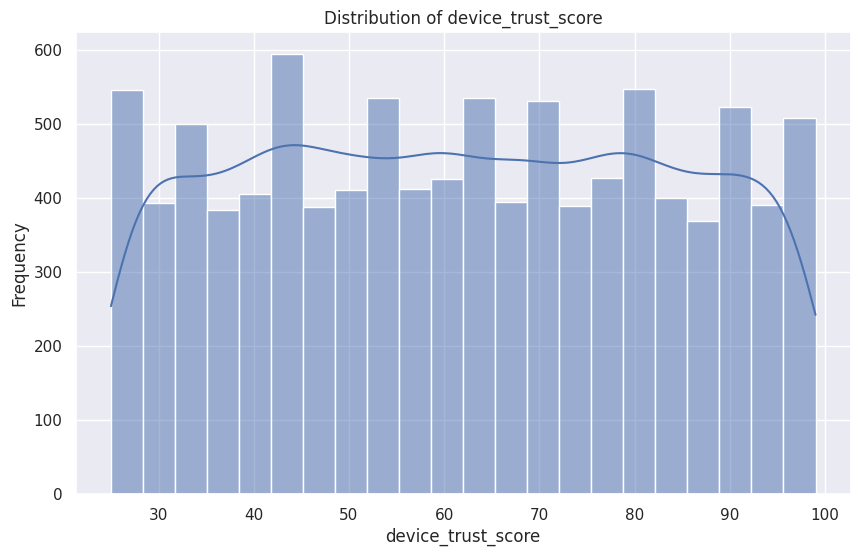

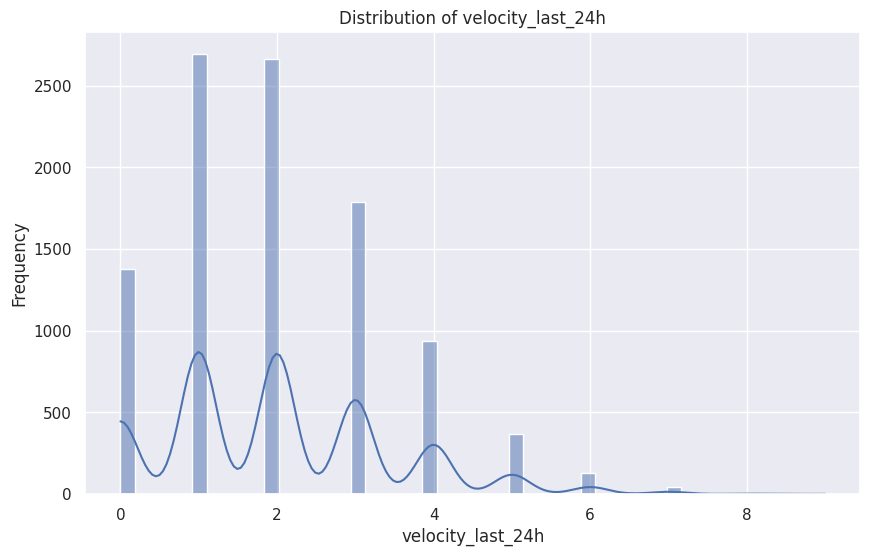

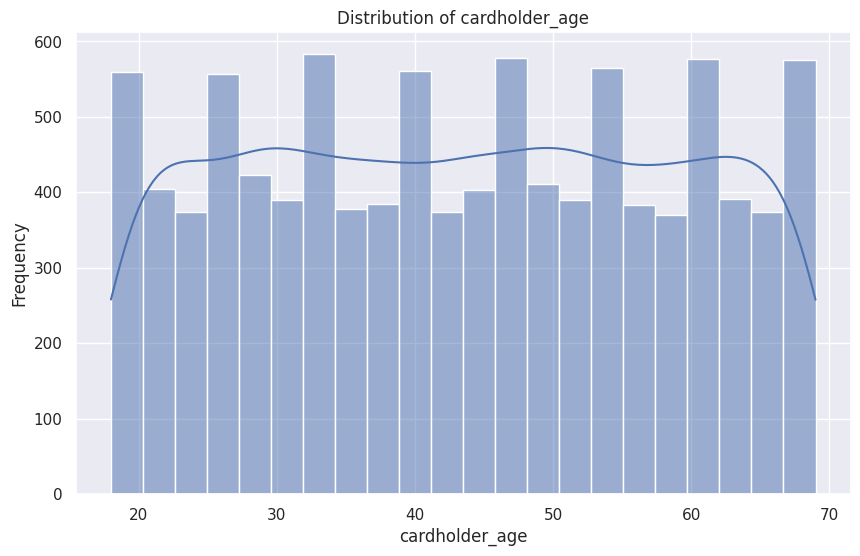

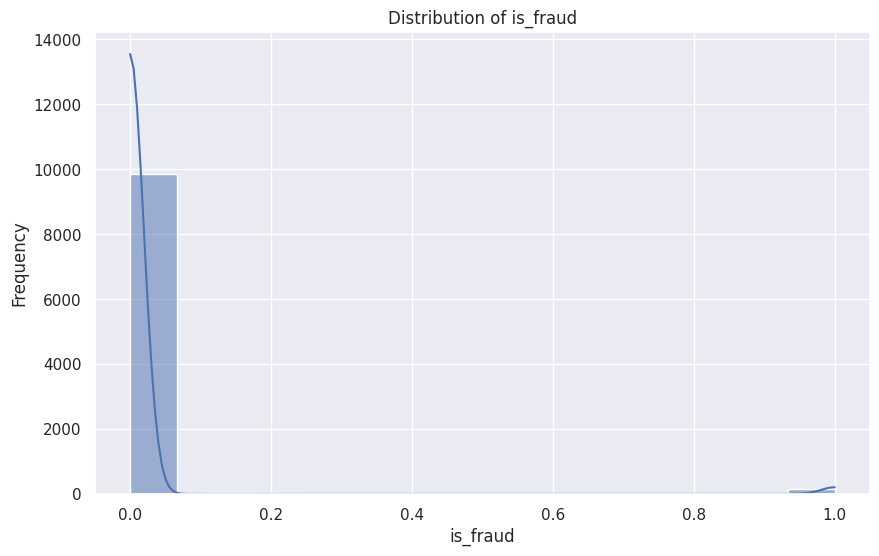

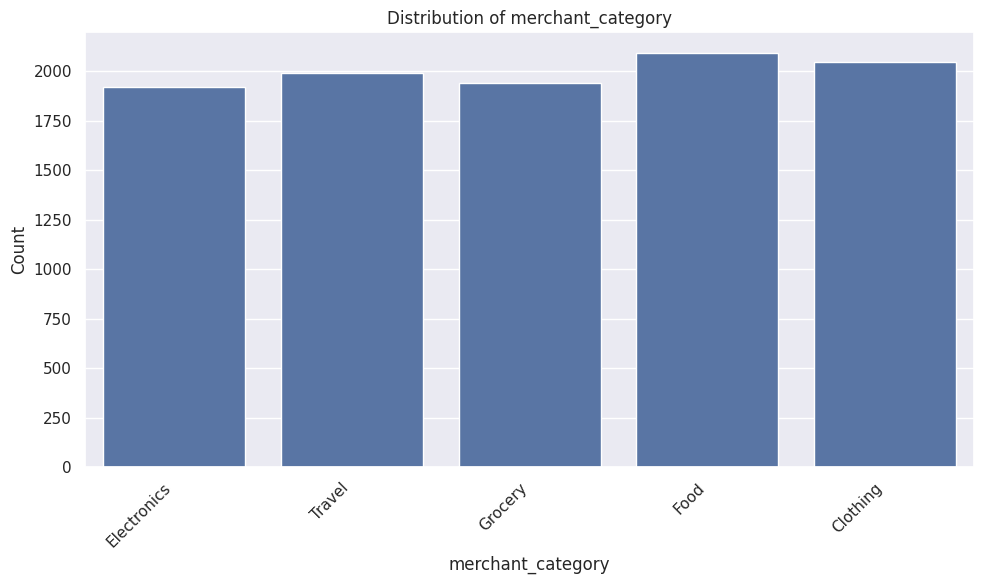

Value counts for merchant_category:
merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64



In [14]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

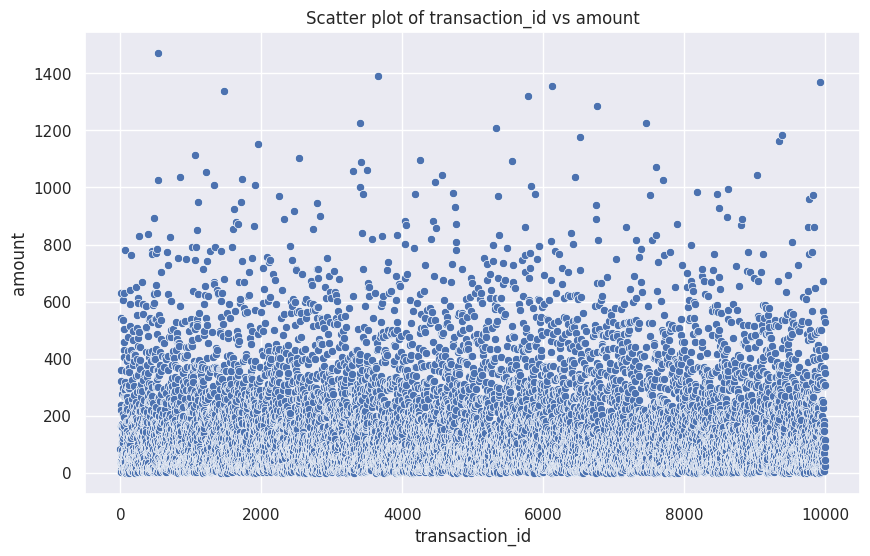

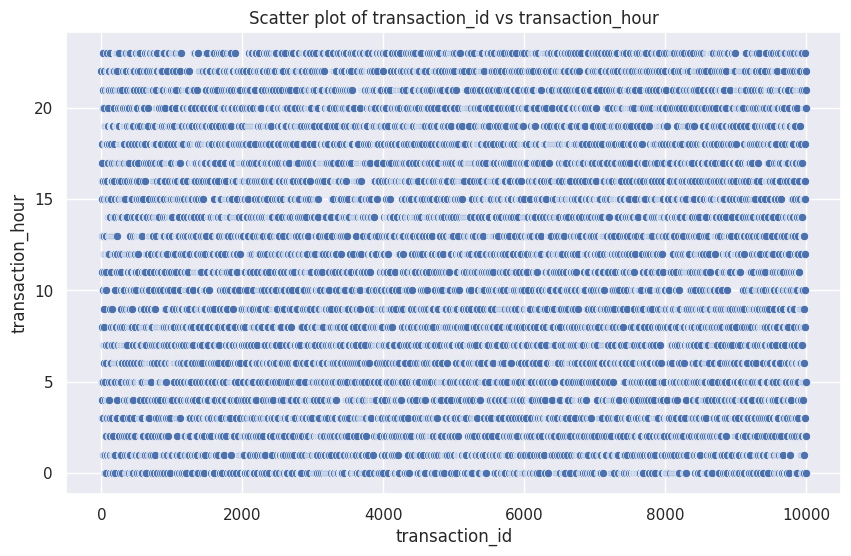

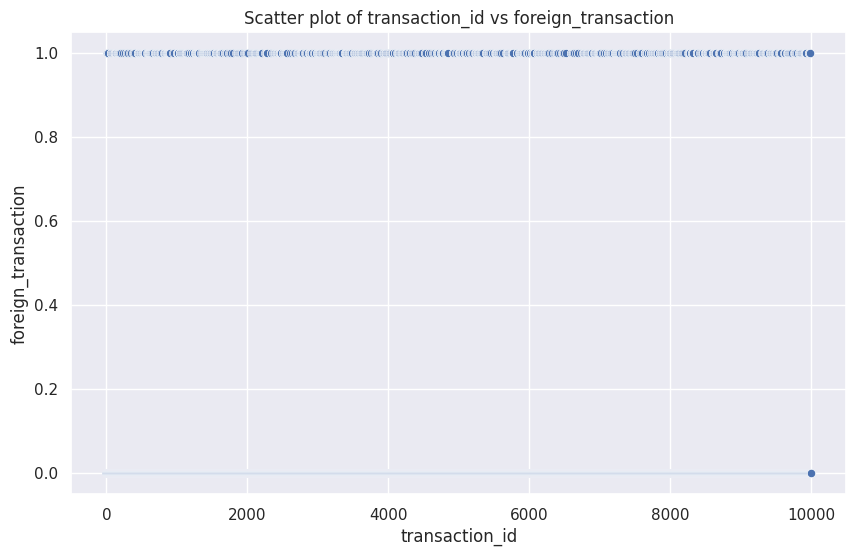

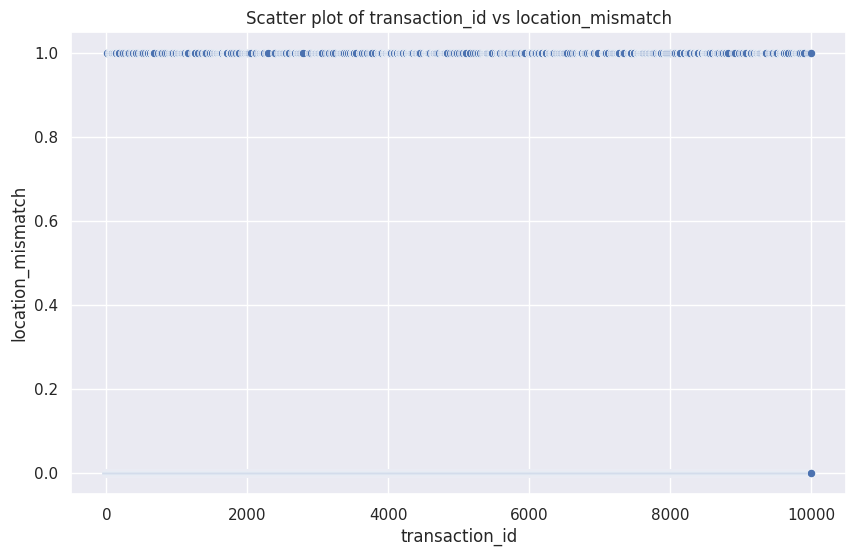

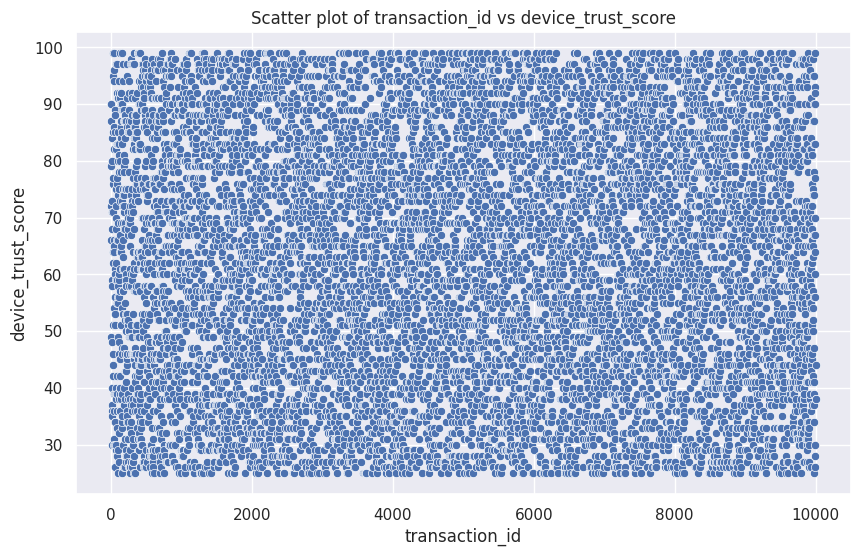

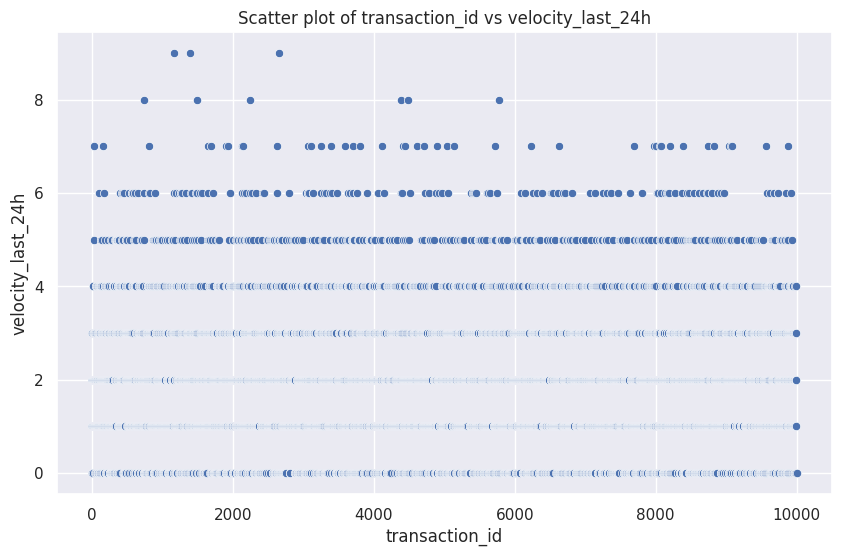

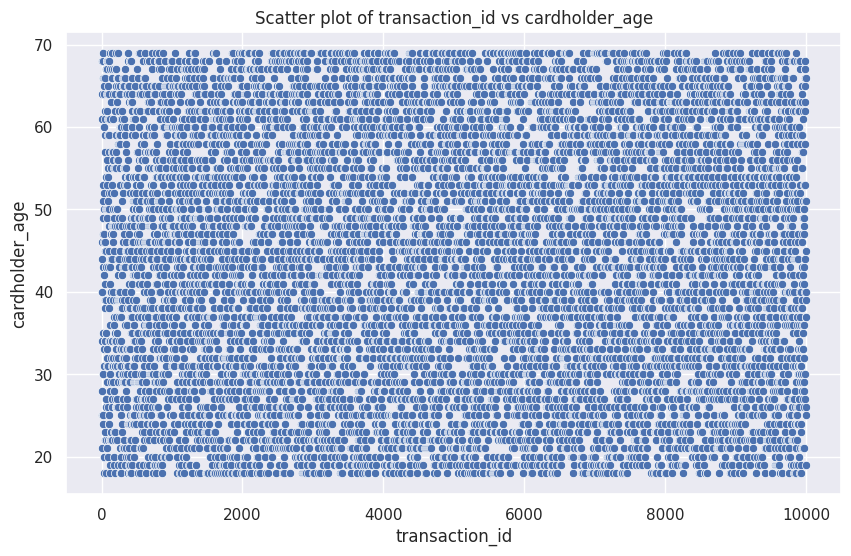

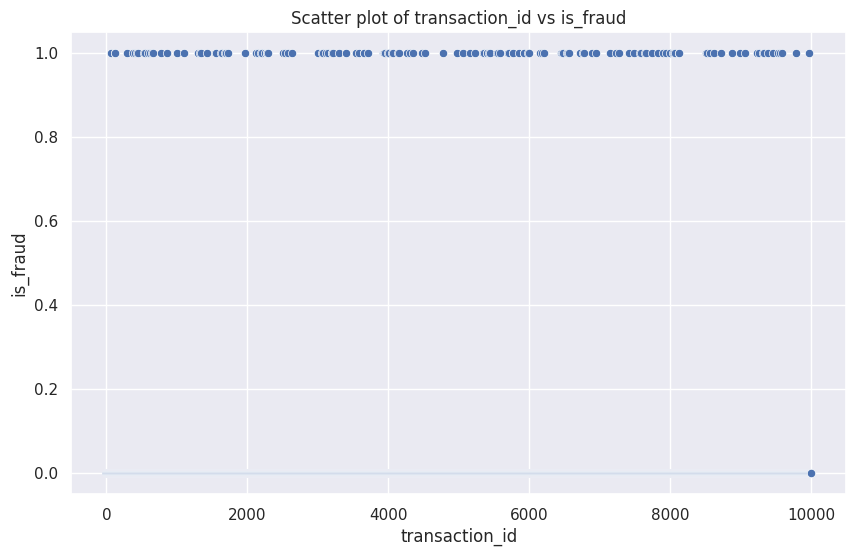

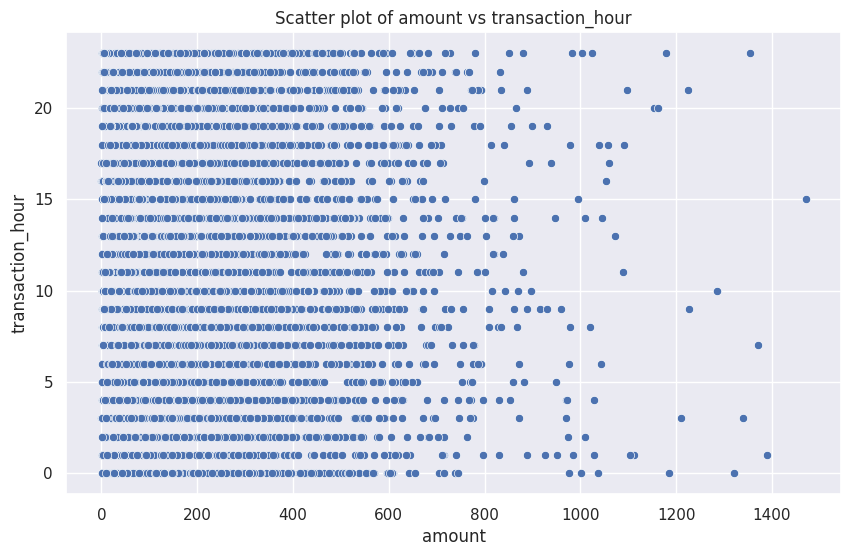

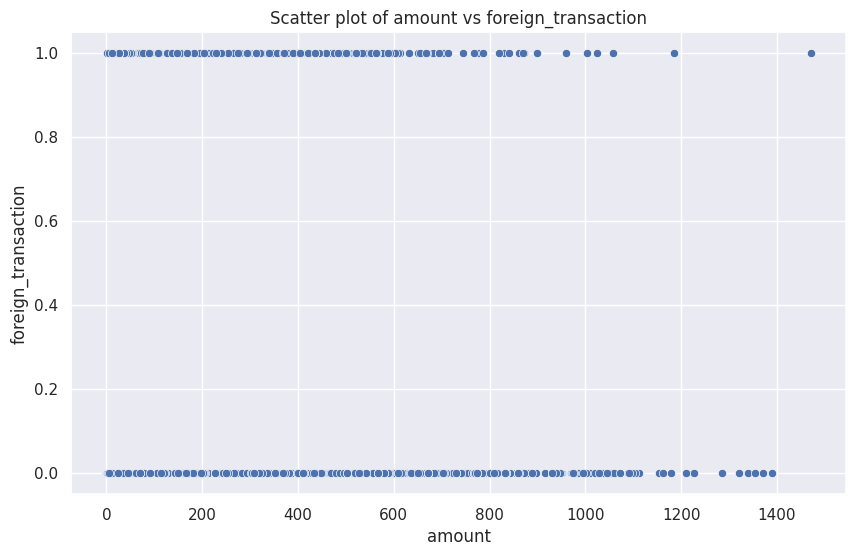

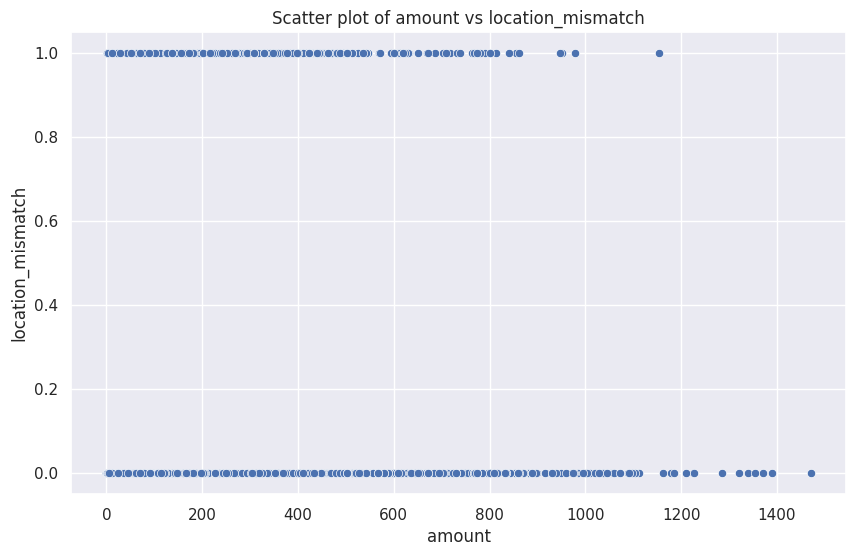

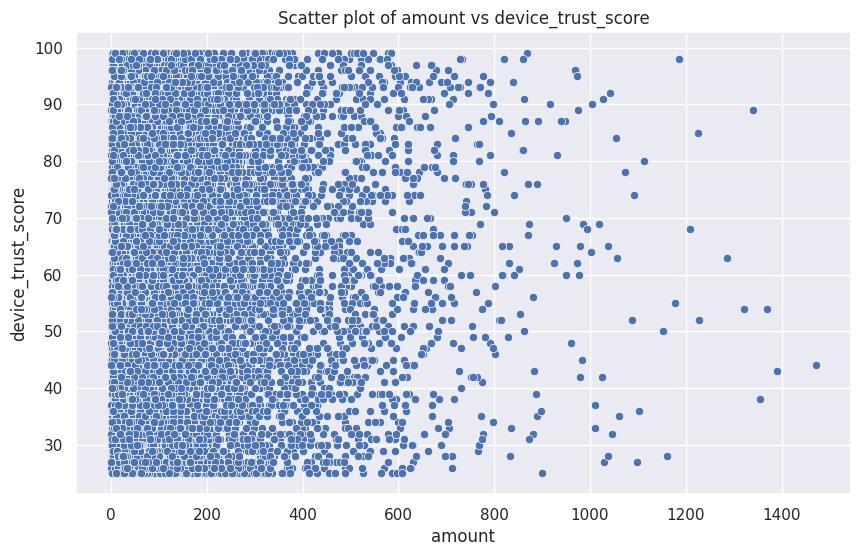

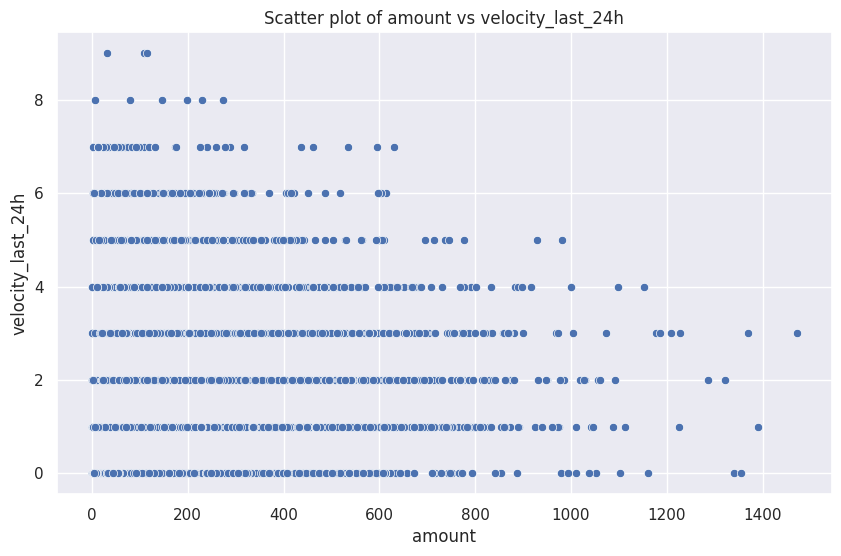

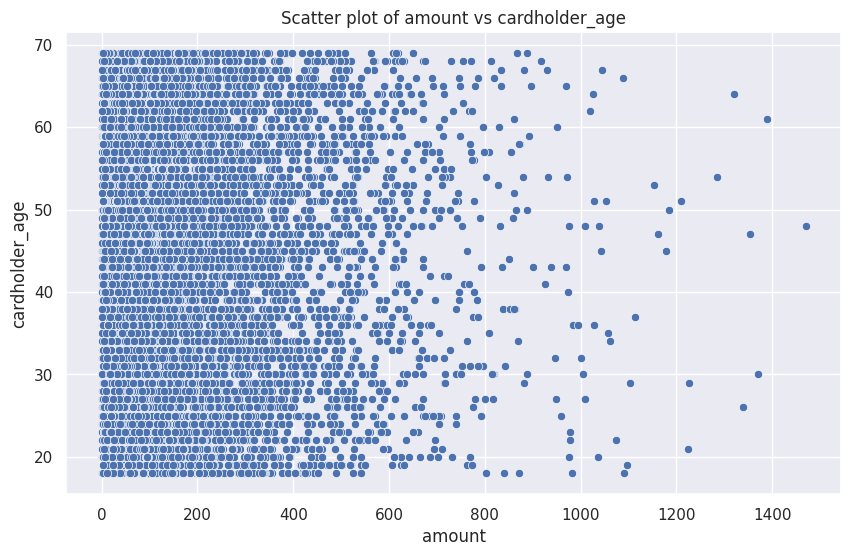

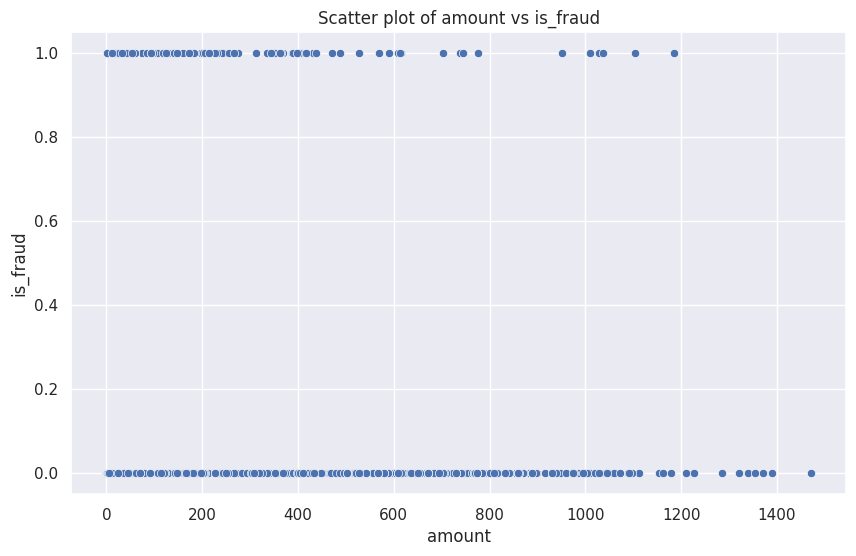

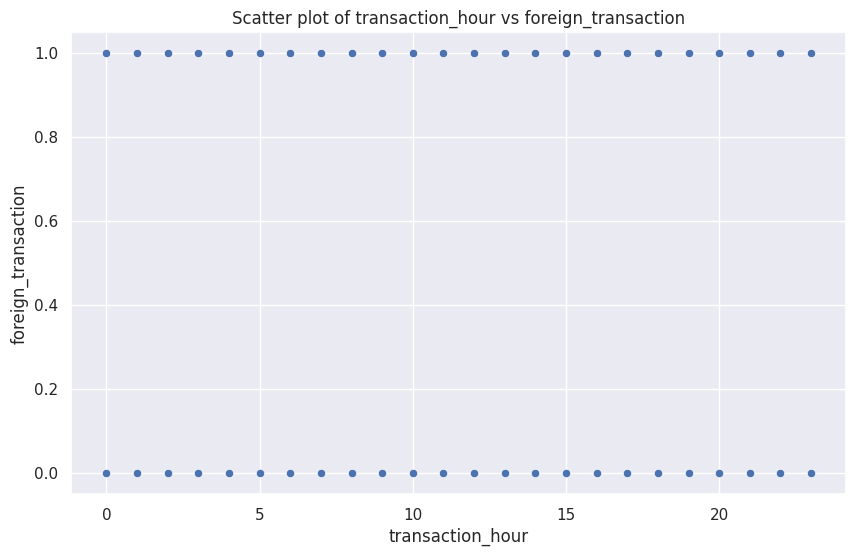

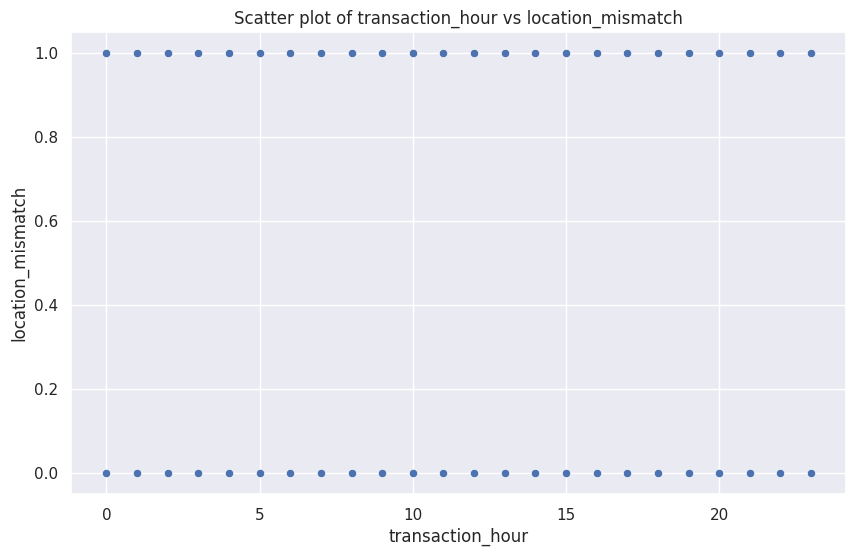

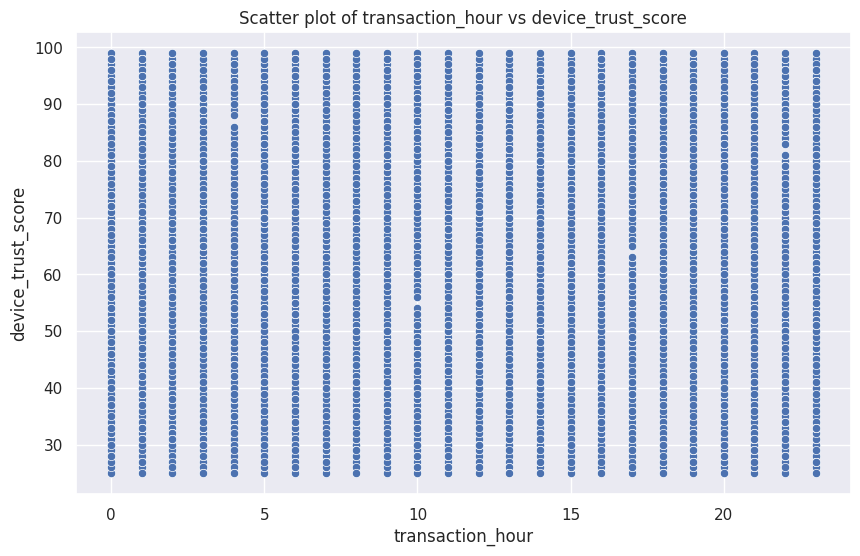

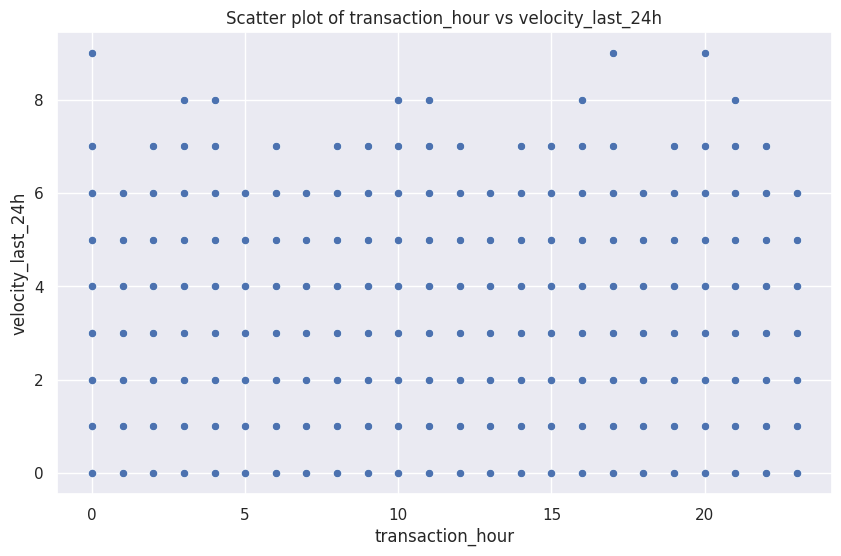

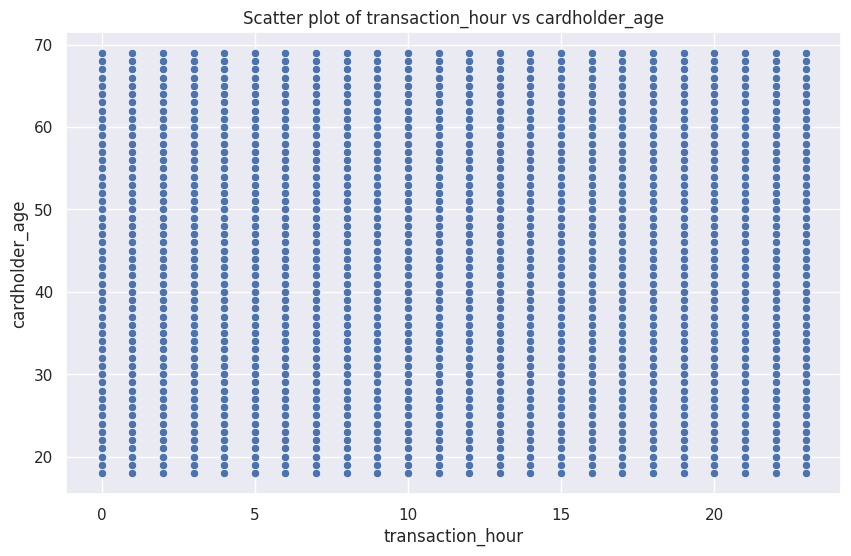

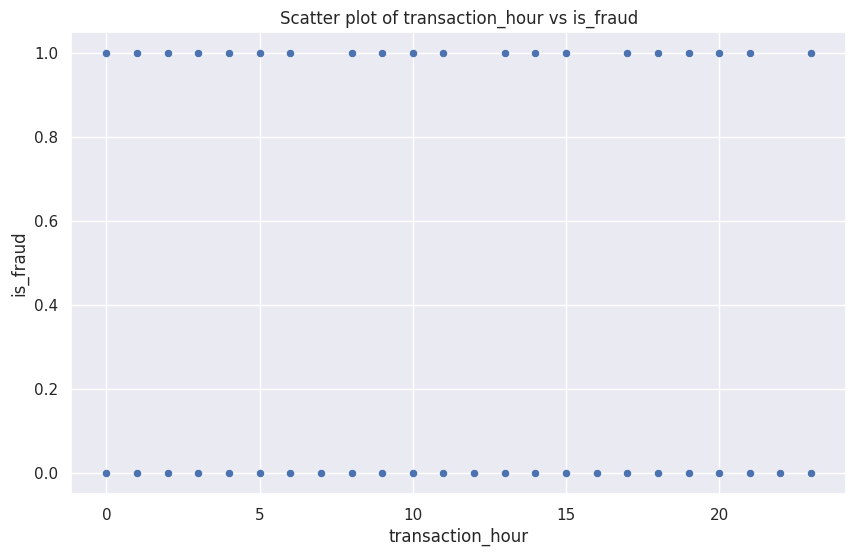

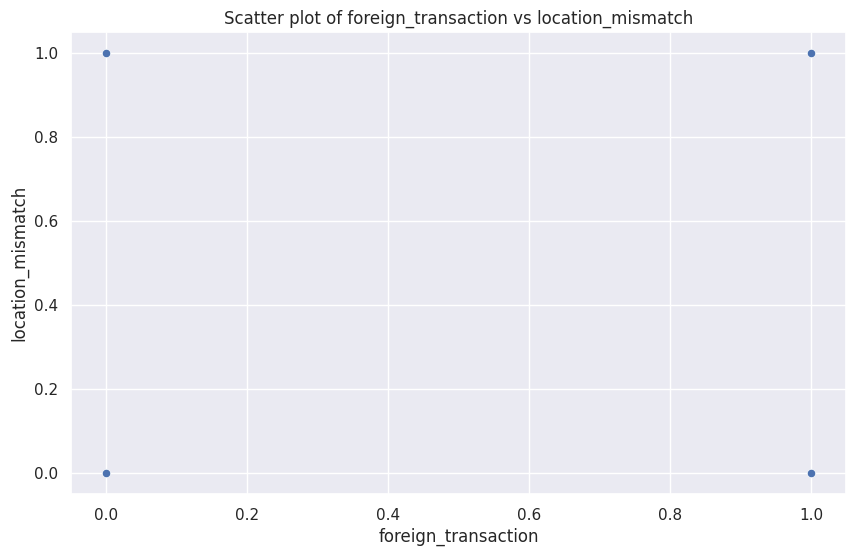

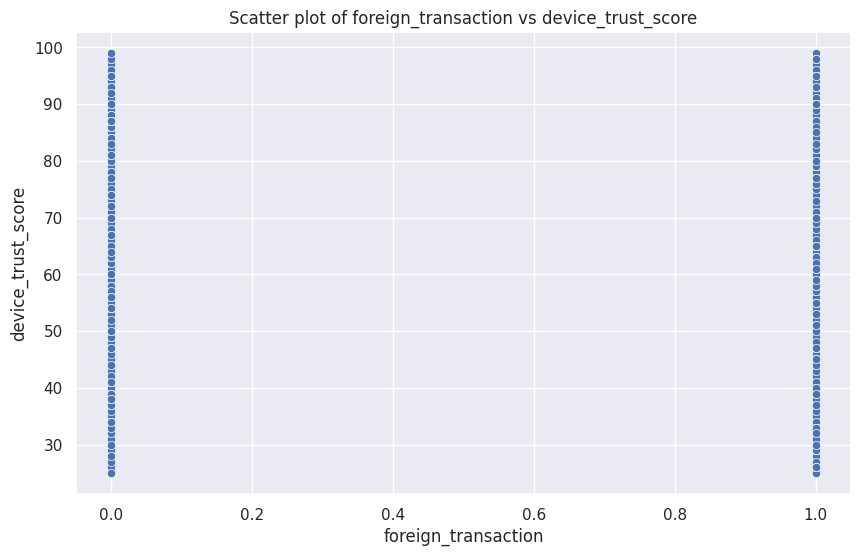

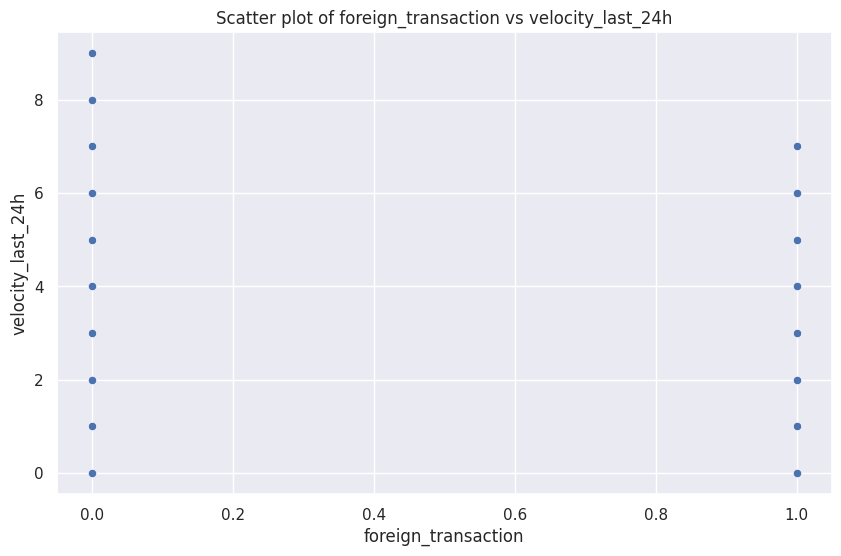

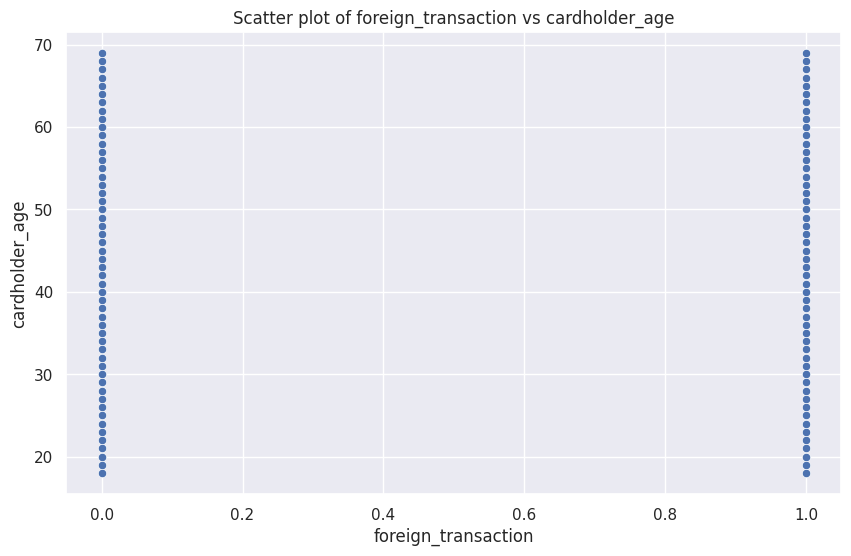

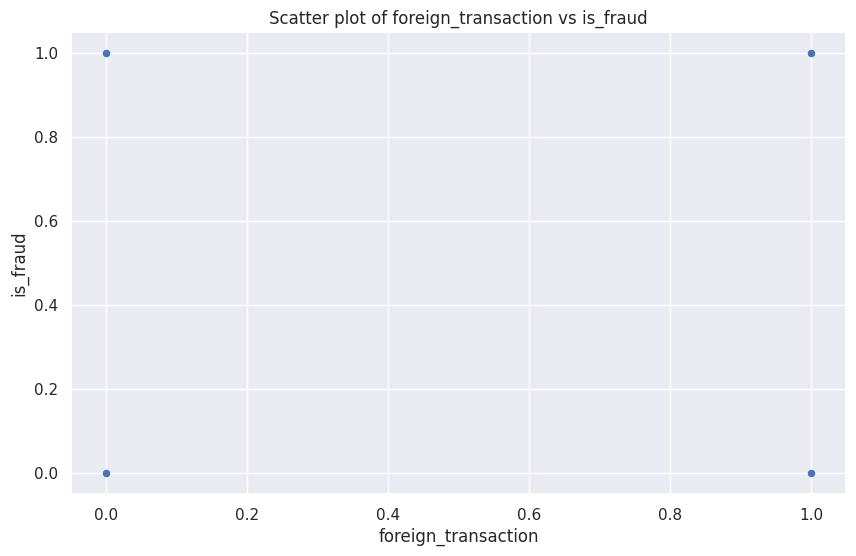

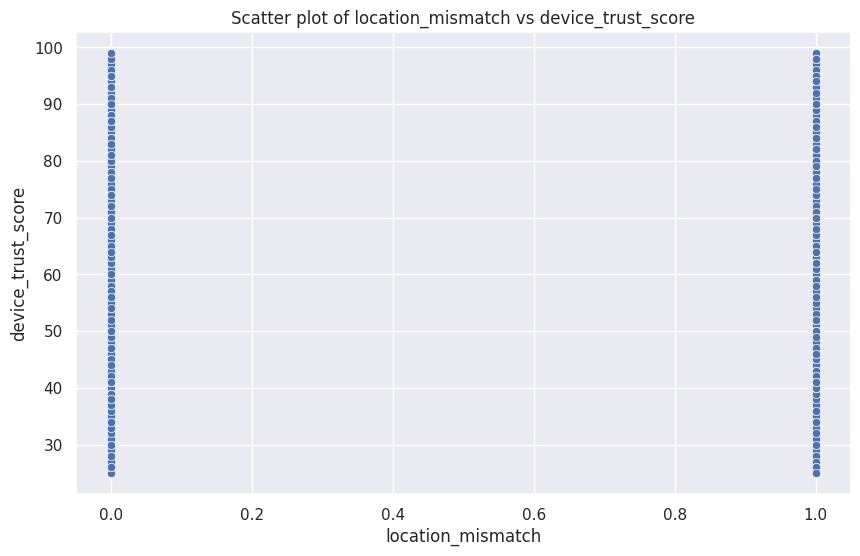

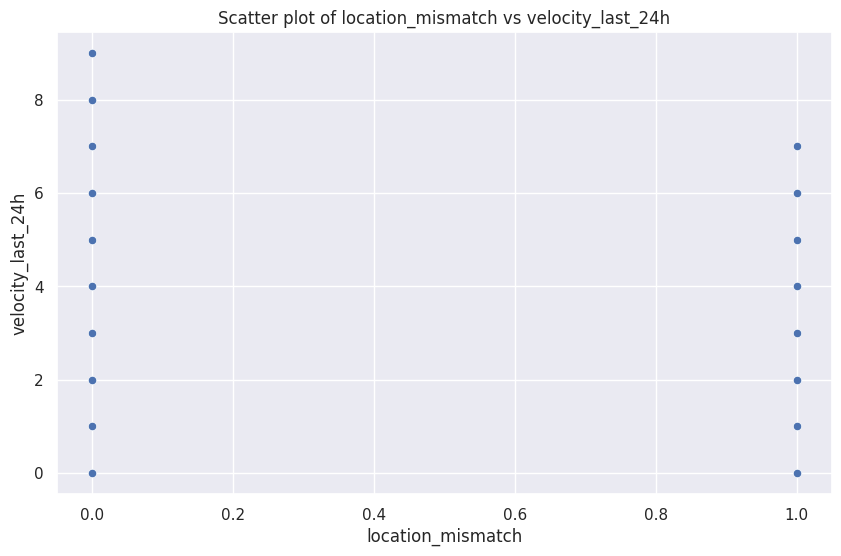

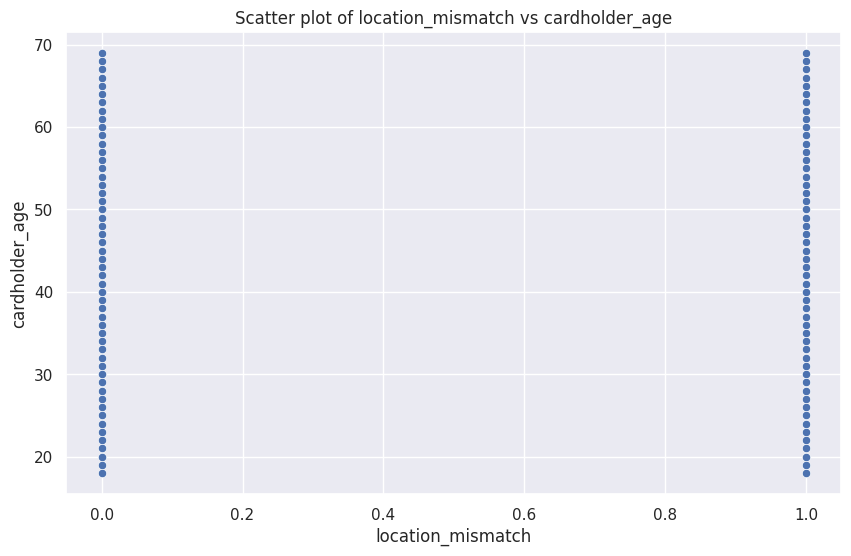

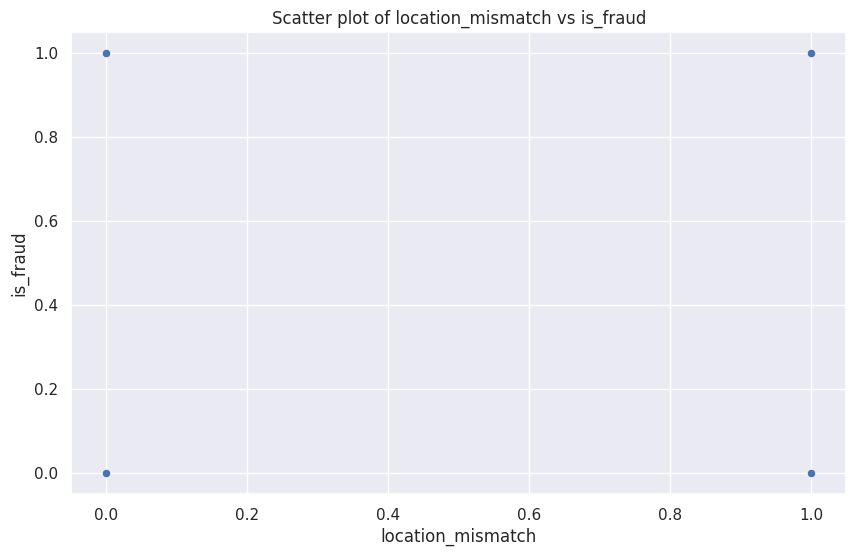

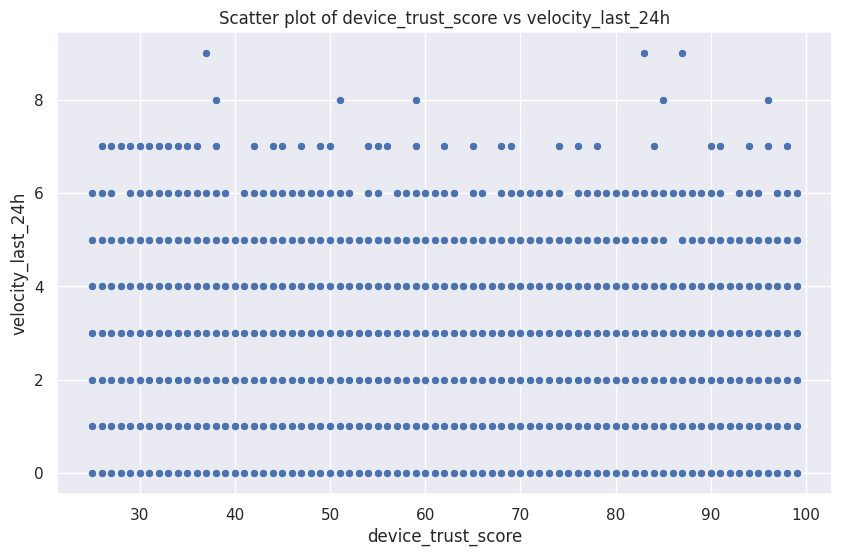

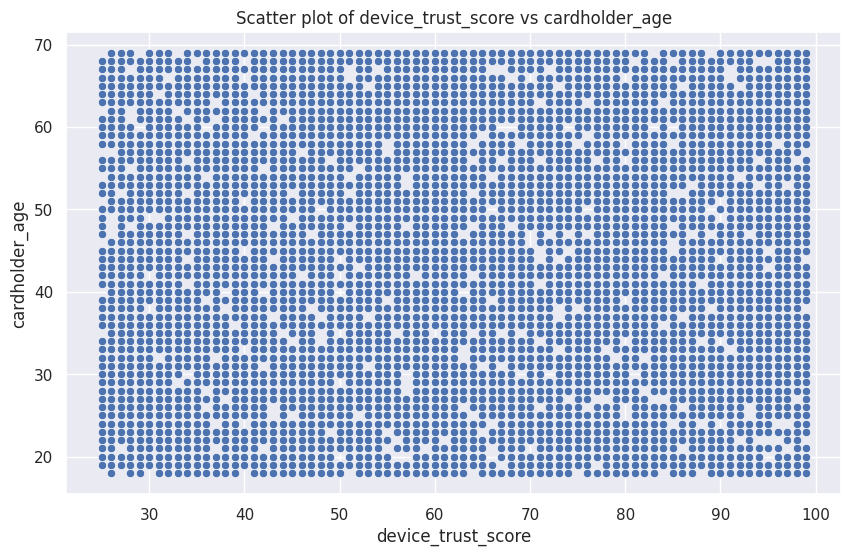

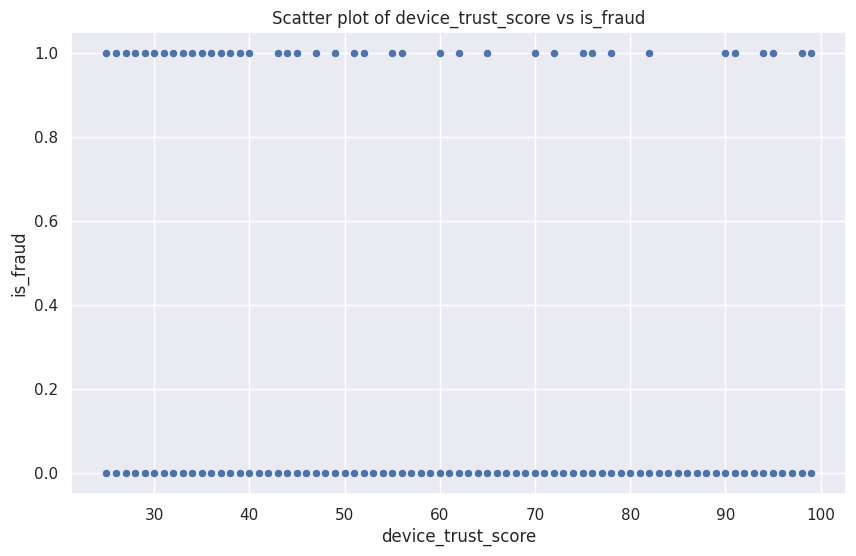

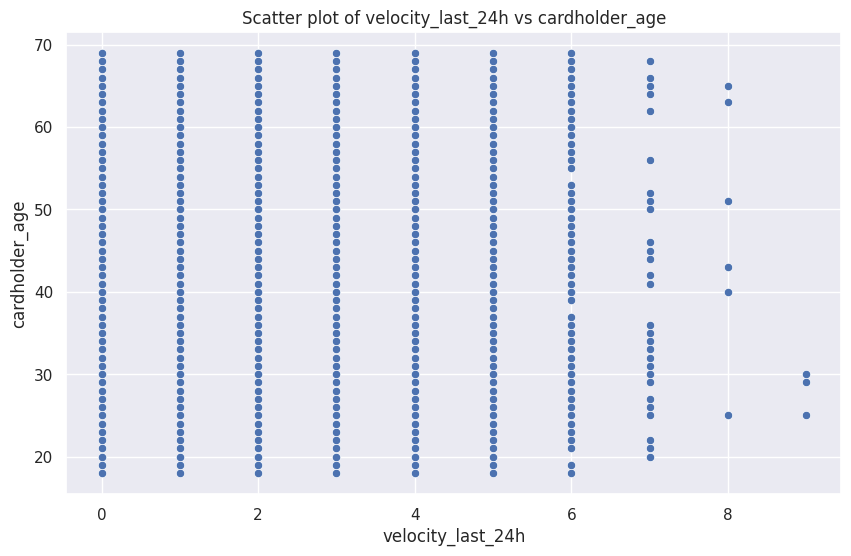

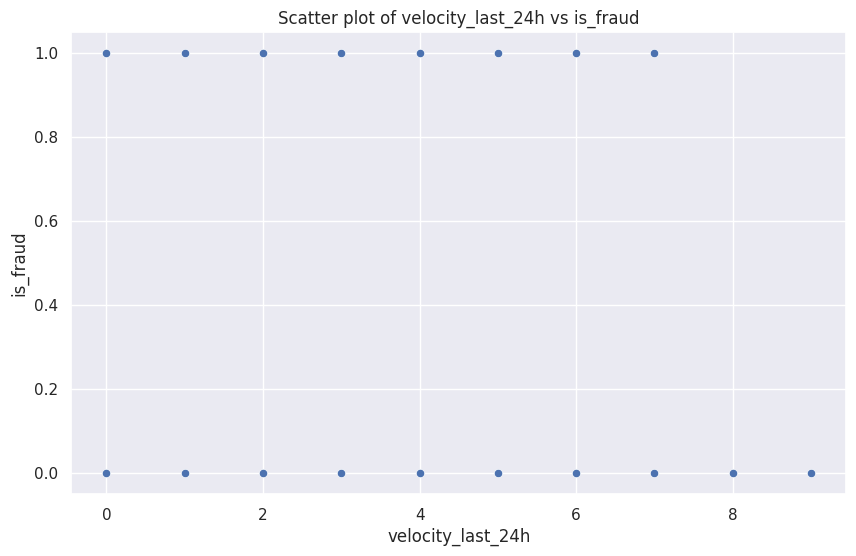

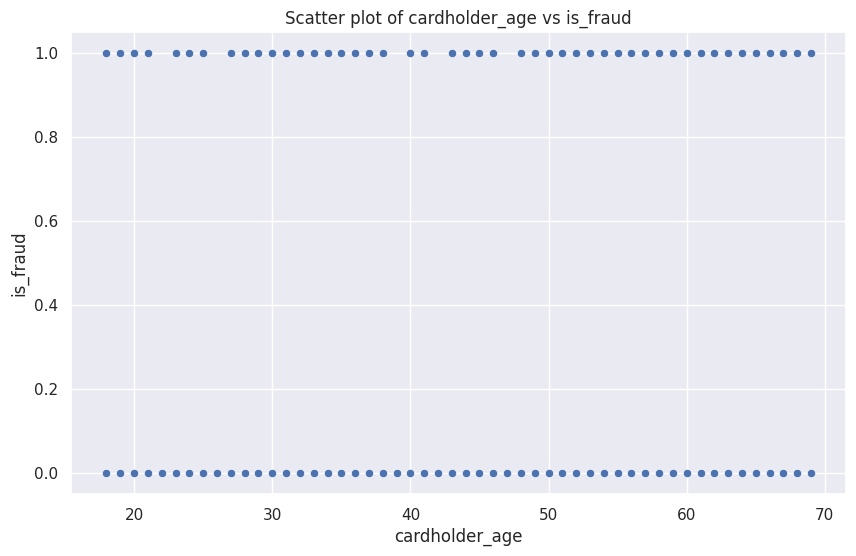

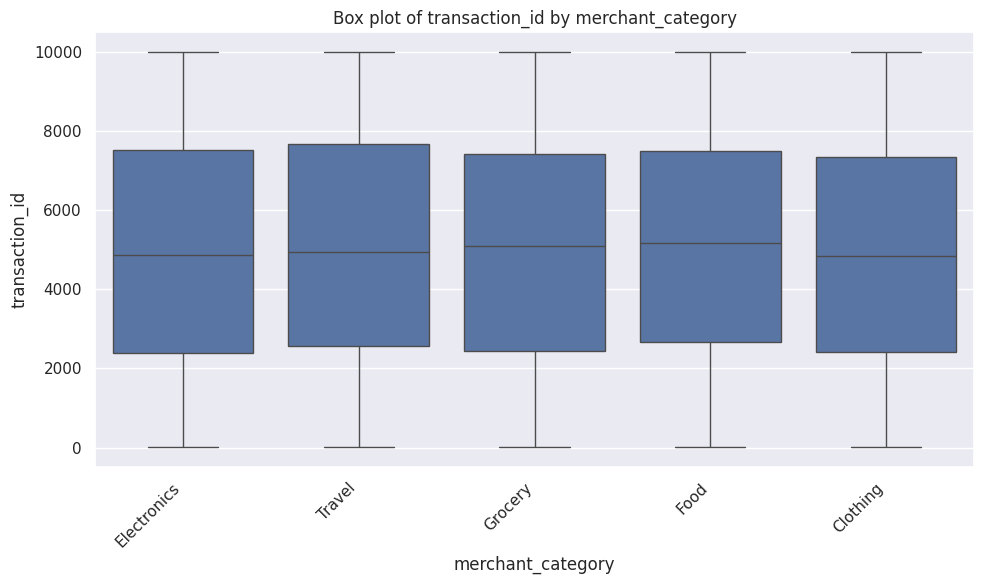

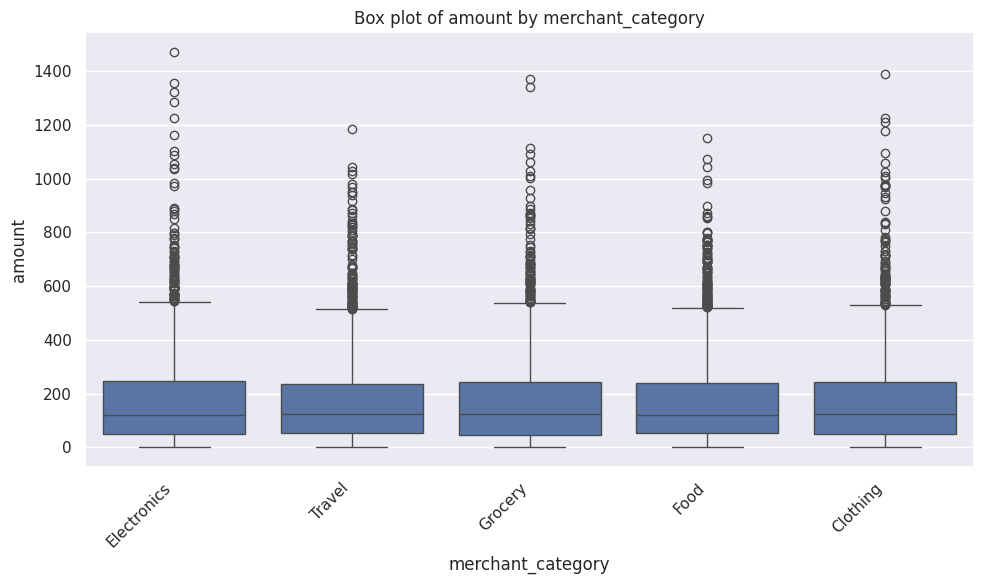

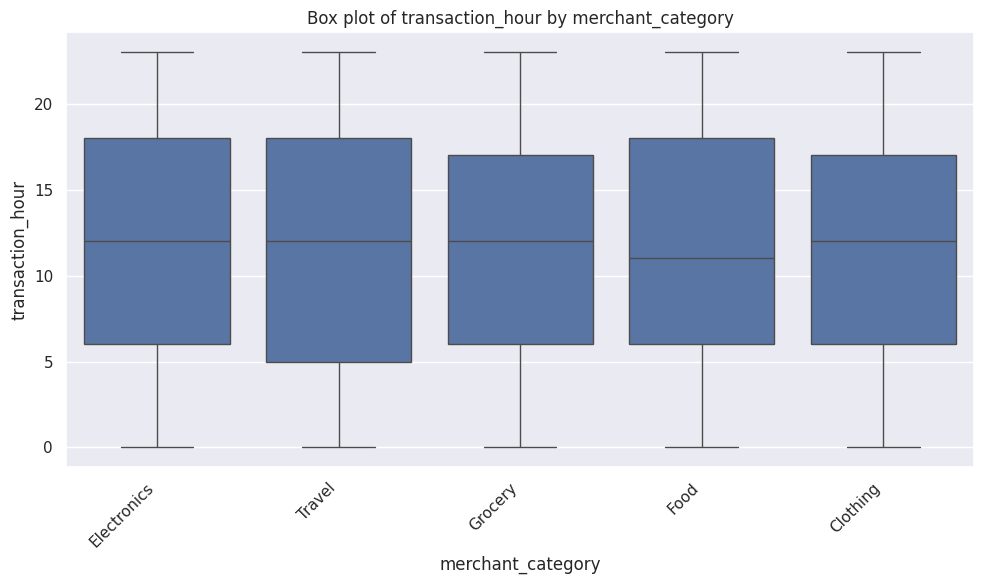

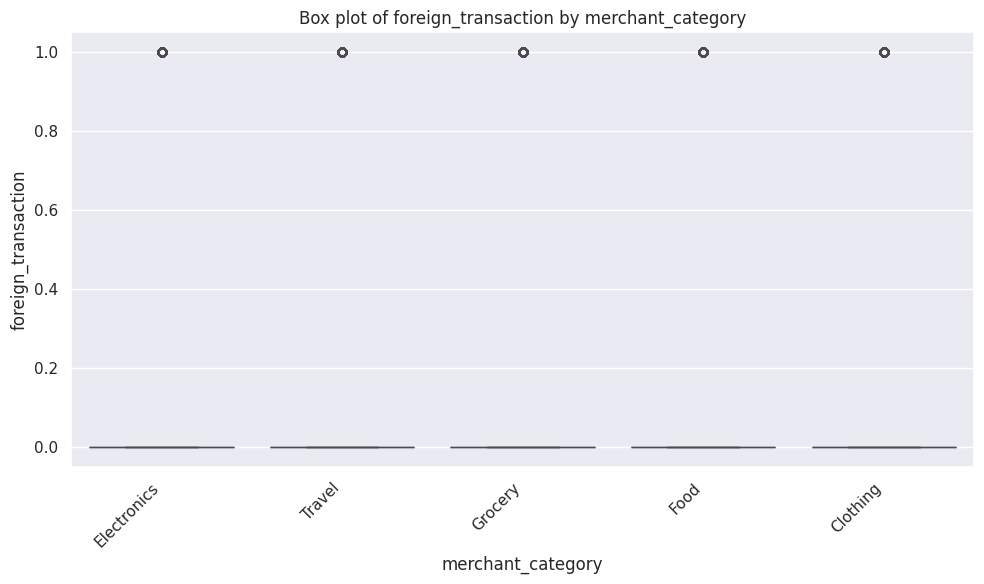

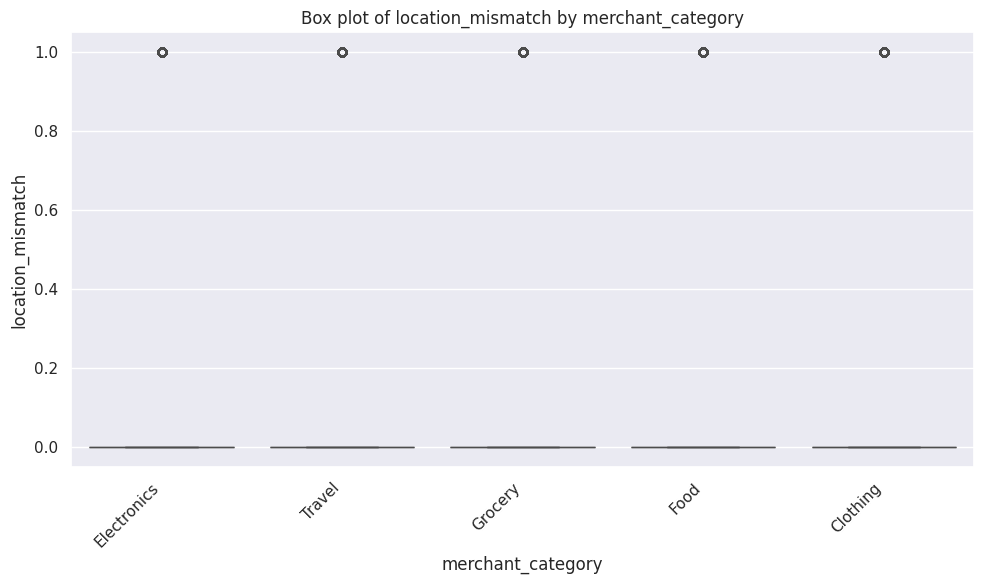

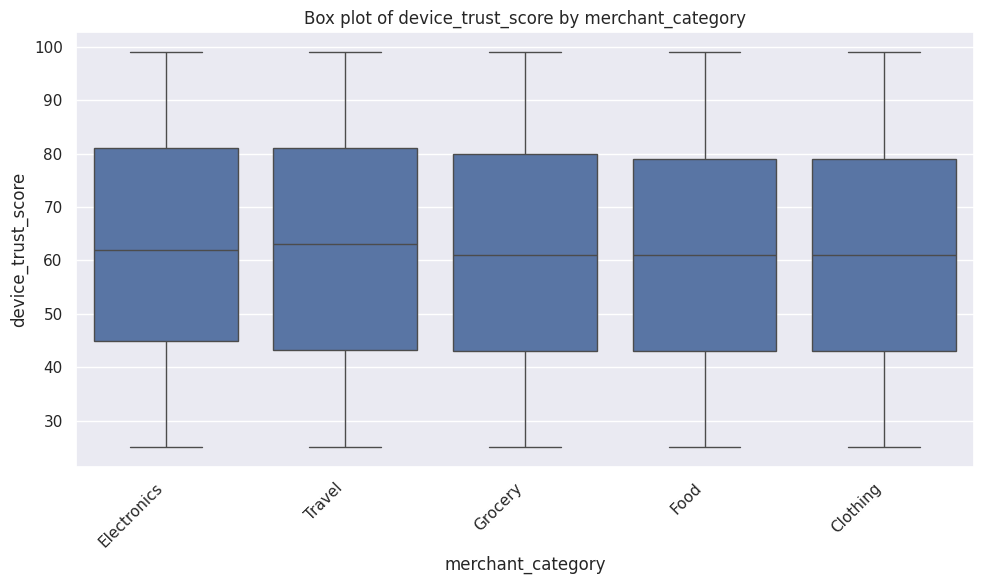

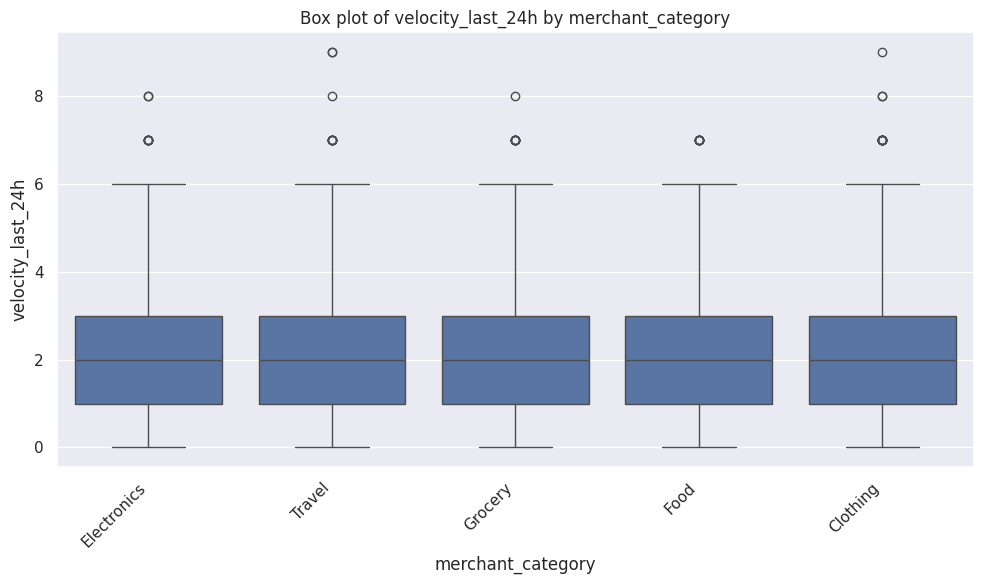

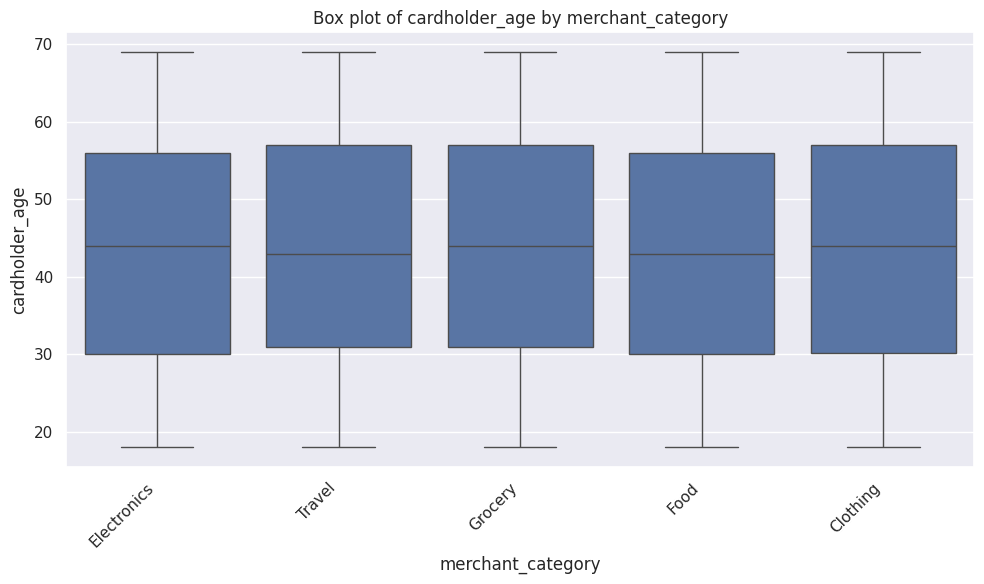

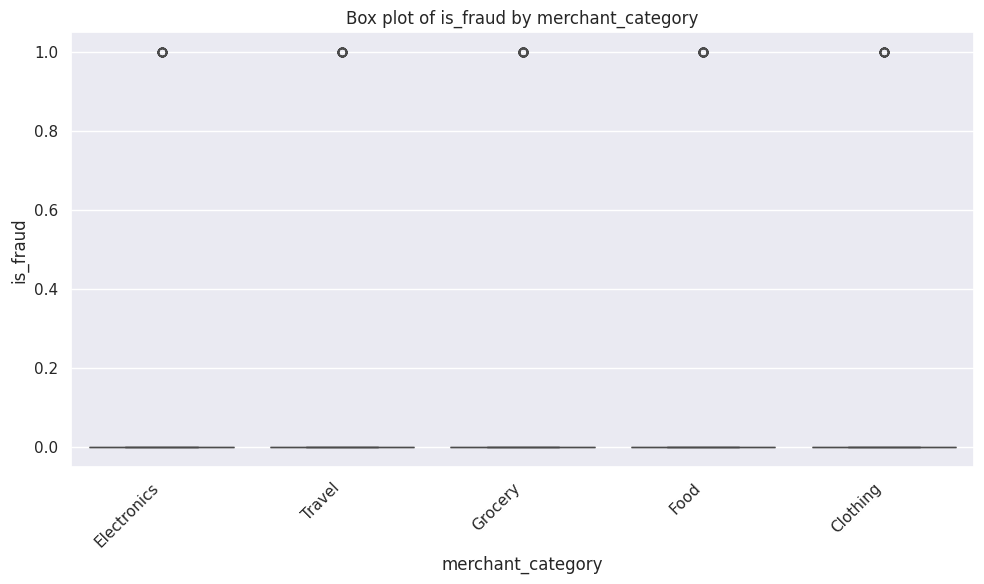

In [15]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude high-cardinality columns that are not suitable for box plots
cols_to_exclude_from_boxplot = ['title', 'original_title', 'overview', 'premiere_date']
filtered_categorical_cols = [col for col in categorical_cols if col not in cols_to_exclude_from_boxplot]

# Iterate through filtered categorical and numerical columns and create box plots
for cat_col in filtered_categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

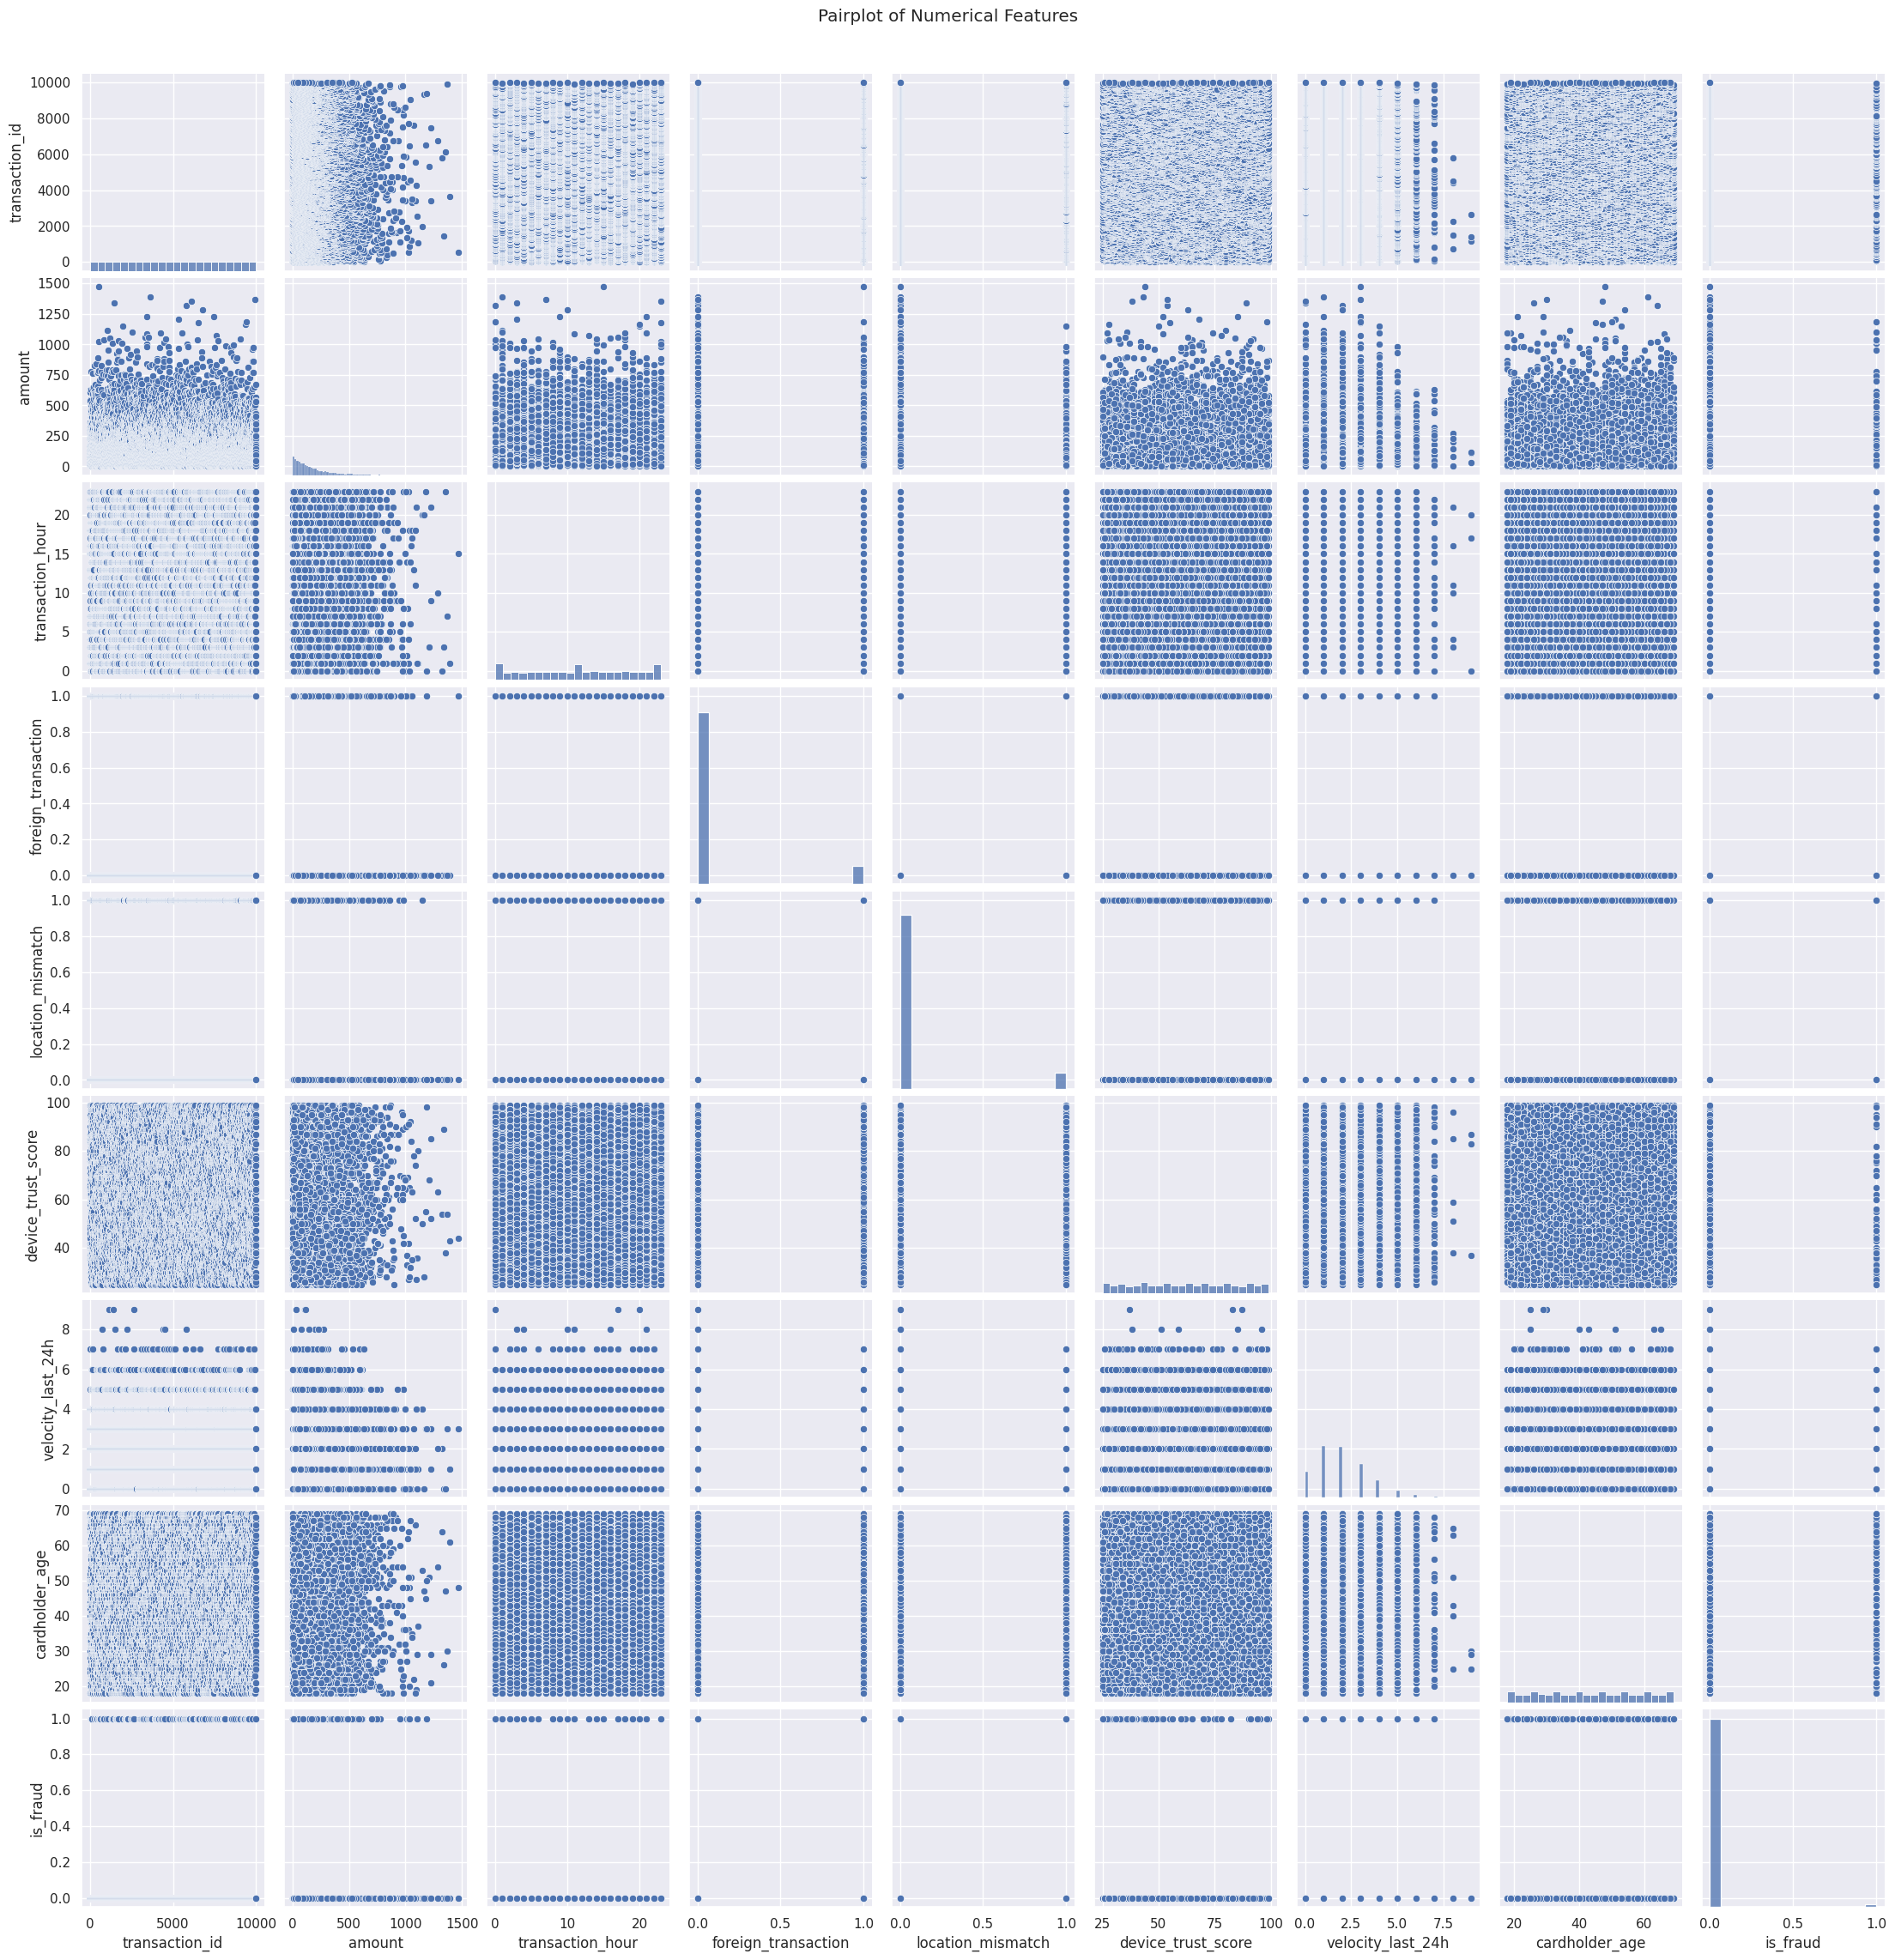

In [16]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

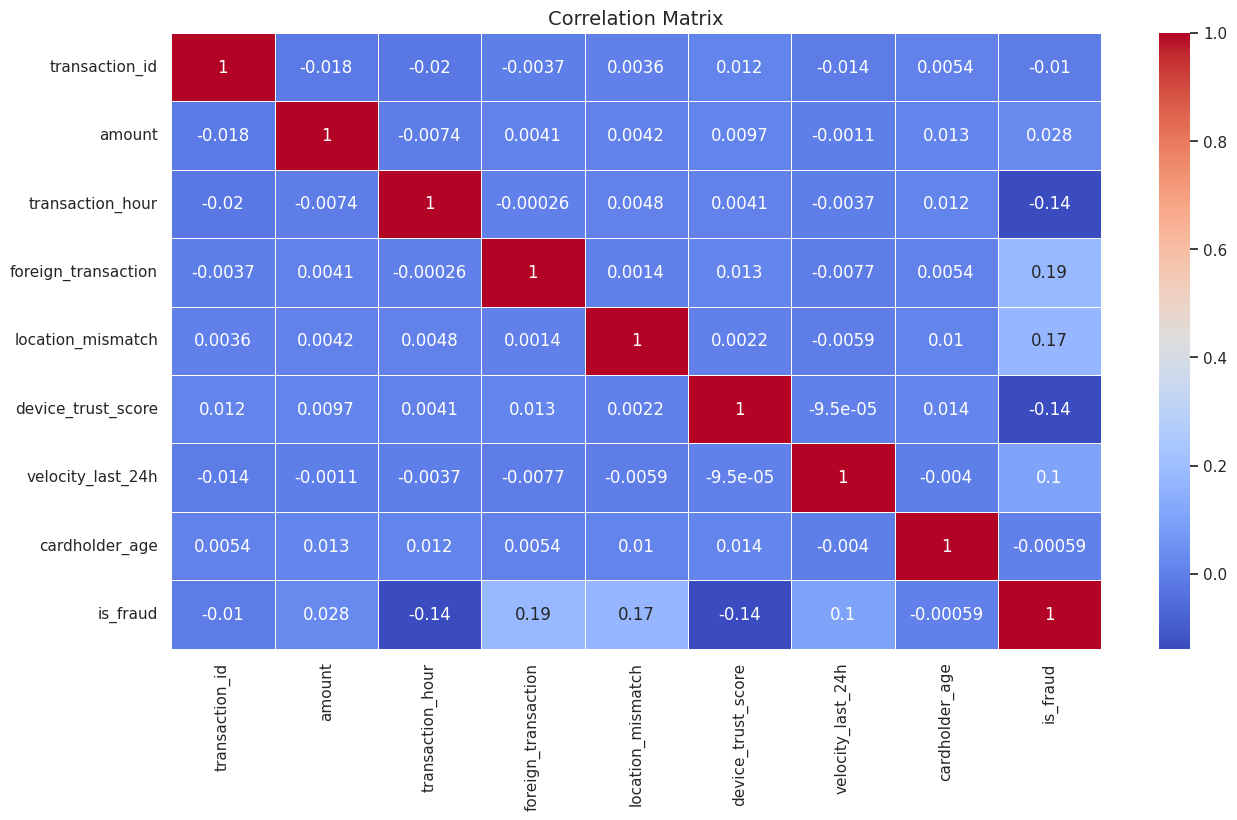

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You